<a href="https://colab.research.google.com/github/skandikonda8/ML-Projects/blob/main/ML_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1
from sklearn.datasets import fetch_california_housing
import pandas as pd

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseValue"] = housing.target     # the number we want to predict (in $100,000s)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
# Cell 2
print(df.shape)            # ~20,640 districts, 9 columns
df.info()                  # dtypes and missing-value check
df.describe()              # ranges of each feature — sane values?
df.isnull().sum()          # any holes?

(20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         20640 non-null  float64
 1   HouseAge       20640 non-null  float64
 2   AveRooms       20640 non-null  float64
 3   AveBedrms      20640 non-null  float64
 4   Population     20640 non-null  float64
 5   AveOccup       20640 non-null  float64
 6   Latitude       20640 non-null  float64
 7   Longitude      20640 non-null  float64
 8   MedHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseValue,0


In [3]:
# Cell 3
import seaborn as sns
import matplotlib.pyplot as plt

df[["MedInc", "MedHouseValue"]].corr()    # correlation between income and house value

,MedInc,MedHouseValue
MedInc,1.000000,0.688075
MedHouseValue,0.688075,1.000000


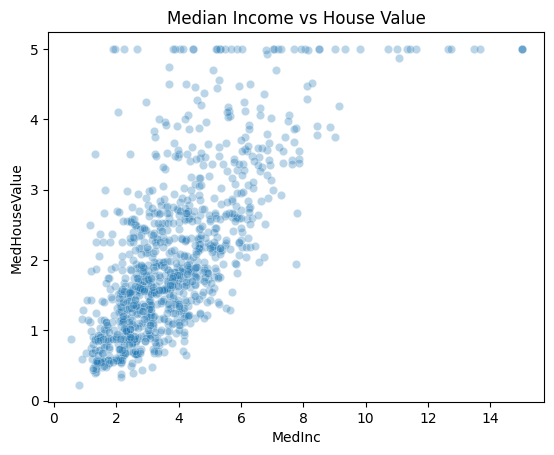

In [4]:
# Cell 4
sns.scatterplot(data=df.sample(1000), x="MedInc", y="MedHouseValue", alpha=0.3)
plt.title("Median Income vs House Value")
plt.show()

In [5]:
# Cell 5
from sklearn.model_selection import train_test_split

X = df.drop(columns=["MedHouseValue"])    # features: everything except the answer
y = df["MedHouseValue"]                    # label: the number we predict

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train districts:", X_train.shape[0], " Test districts:", X_test.shape[0])

Train districts: 16512  Test districts: 4128


In [6]:
# Cell 6
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)        # TEACH — same .fit() you already know

LinearRegression()

In [7]:
# Cell 7
predictions = model.predict(X_test)    # predict house values for hidden districts

# look at a few predictions vs reality
comparison = pd.DataFrame({
    "Actual": y_test[:10].values,
    "Predicted": predictions[:10].round(2)
})
print(comparison)

    Actual  Predicted
0  0.47700       0.72
1  0.45800       1.76
2  5.00001       2.71
3  2.18600       2.84
4  2.78000       2.60
5  1.58700       2.01
6  1.98200       2.65
7  1.57500       2.17
8  3.40000       2.74
9  4.46600       3.92


In [8]:
# Cell 8
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE: ", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²:  ", round(r2, 3))

MAE:  0.533
RMSE: 0.746
R²:   0.576


In [9]:
# Cell 9
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("Linear Regression R²:", round(r2, 3))
print("Random Forest R²:    ", round(r2_score(y_test, rf_preds), 3))

Linear Regression R²: 0.576
Random Forest R²:     0.805
